# EM Force Interpolation Example

This notebook demonstrates interpolating vector EM force values (Fx, Fy, Fz) from source to destination mesh using the DISTANCE_WEIGHTED kernel with k=5 nearest neighbors.

In [21]:
from interpcore.interpolator import Interpolator
from interpcore.config import InterpolationConfig, QUERY_TYPE, INTERPOLATED_LOAD_TYPE
from interpcore.kernels import INTERPOLATION_KERNEL

## Configure and Run Interpolation

In [22]:
# Create configuration for DISTANCE_WEIGHTED kernel with EM_FORCE load type
config = InterpolationConfig(
    method=QUERY_TYPE.RADIUS,
    param=3,
    max_distance=2.0,
    coincidence_tolerance=0.01,
    kernel=INTERPOLATION_KERNEL.DISTANCE_WEIGHTED,
    multithread=False,
    interpolated_load=INTERPOLATED_LOAD_TYPE.EM_FORCE
)

# Define file column indices
file_idx = {"ids": 0, "dest_x": 1, "src_x": 1, "val": 4}

# Create interpolator
interpolator = Interpolator(
    path_to_src_folder="source_data",
    path_to_dest_mesh="destination_mesh.txt",
    config=config,
    file_idx=file_idx
)

# Run interpolation
interpolator.interpolate_all()
print("Interpolation completed!")

100%|██████████| 1/1 [00:00<00:00, 113.32it/s]

Interpolation completed!


## Export to APDL format

In [23]:
from tempfile import TemporaryDirectory

with TemporaryDirectory() as tmp_dir:
    interpolator.export_to_ansys(tmp_dir)

    # Preview the exported file content (Fx, Fy, Fz components)
    with open(f"{tmp_dir}/interpolated_em_force_data.txt", "r") as f:
        for line in f.readlines()[:9]:  # Show 3 nodes x 3 components
            print(line.strip())

F, 201.0, Fx, 3.206380583833244
F, 202.0, Fx, 5.674665237779757
F, 203.0, Fx, 7.195468574283119
F, 204.0, Fx, 8.220183643202652
F, 205.0, Fx, 9.406846707532717
F, 206.0, Fx, 10.568106604764903
F, 207.0, Fx, 11.747525886438744
F, 208.0, Fx, 12.945990497481683
F, 209.0, Fx, 14.146807985286568


## View Results

Build VTK output for visualization. For vector fields, we'll use glyphs (arrows) to show force direction and magnitude.

In [24]:
import pyvista as pv
import matplotlib.pyplot as plt

interpolator.build_vtk_output(outdir=None)

Visualize the vector fields using glyphs to show force direction and magnitude

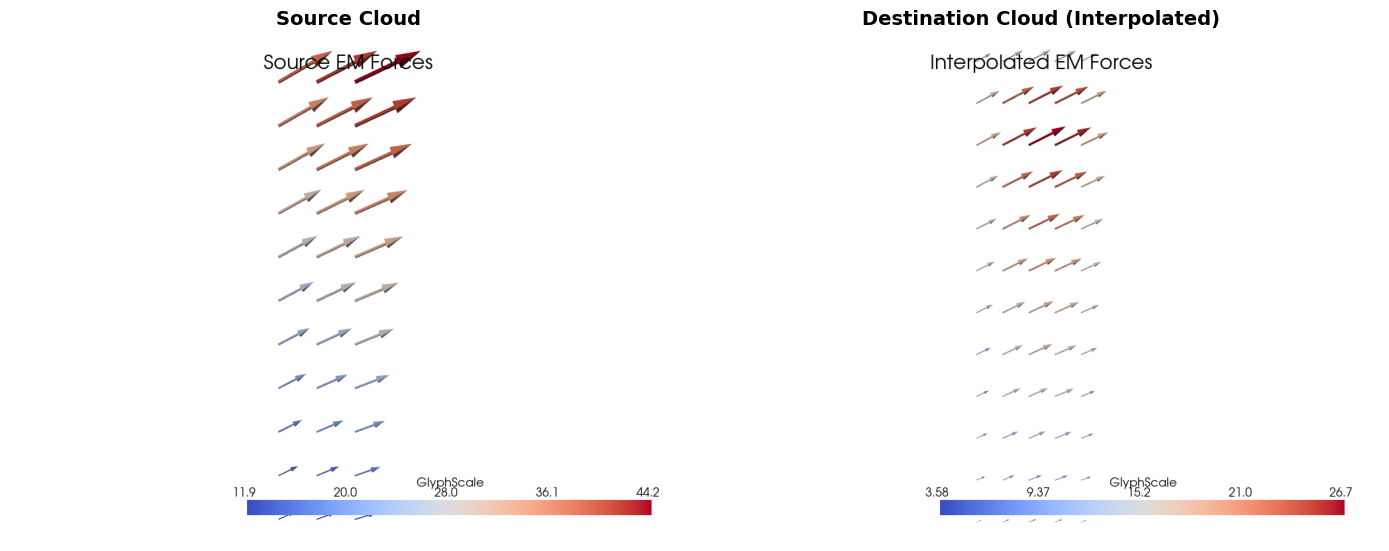

In [25]:
source_cloud = interpolator.src_vtk["em_force_data"]
dest_cloud = interpolator.dest_vtk["em_force_data"]

# Create a static plot comparing the two clouds side by side with glyphs
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot source cloud with vector glyphs
plotter_src = pv.Plotter(off_screen=True)
glyphs_src = source_cloud.glyph(orient="Value", scale="Value", factor=0.03)
plotter_src.add_mesh(glyphs_src, cmap='coolwarm', show_scalar_bar=True)
plotter_src.add_mesh(source_cloud, color='lightgray', point_size=5, render_points_as_spheres=True)
plotter_src.add_title('Source EM Forces', font_size=12)
plotter_src.camera_position = 'xy'
img_src = plotter_src.screenshot(return_img=True)
plotter_src.close()

# Plot destination cloud with vector glyphs
plotter_dest = pv.Plotter(off_screen=True)
glyphs_dest = dest_cloud.glyph(orient="Value", scale="Value", factor=0.03)
plotter_dest.add_mesh(glyphs_dest, cmap='coolwarm', show_scalar_bar=True)
plotter_dest.add_mesh(dest_cloud, color='lightgray', point_size=5, render_points_as_spheres=True)
plotter_dest.add_title('Interpolated EM Forces', font_size=12)
plotter_dest.camera_position = 'xy'
img_dest = plotter_dest.screenshot(return_img=True)
plotter_dest.close()

# Display in matplotlib
axes[0].imshow(img_src)
axes[0].axis('off')
axes[0].set_title('Source Cloud', fontsize=14, fontweight='bold')

axes[1].imshow(img_dest)
axes[1].axis('off')
axes[1].set_title('Destination Cloud (Interpolated)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()